In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# Load the original dataset
raw_path = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_features = pd.read_csv(raw_path)

# Reproduce documented TotalCharges cleaning
total_charges_text = df_features["TotalCharges"].str.strip().replace("", np.nan)
blank_total_charges = total_charges_text.isna()

assert (df_features.loc[blank_total_charges, "tenure"] == 0).all()

df_features["TotalCharges"] = (
    pd.to_numeric(total_charges_text, errors="raise")
    .fillna(0)
)

# Recreate engineered features
df_features["ChurnFlag"] = (df_features["Churn"] == "Yes").astype(int)

df_features["HasInternet"] = (
    df_features["InternetService"] != "No"
).astype(int)

df_features["HasPhone"] = (
    df_features["PhoneService"] == "Yes"
).astype(int)

df_features["AutoPayment"] = (
    df_features["PaymentMethod"]
    .isin(["Bank transfer (automatic)", "Credit card (automatic)"])
).astype(int)

add_on_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

df_features["ServiceCount"] = (
    df_features[add_on_columns]
    .eq("Yes")
    .sum(axis=1)
)

print("Prepared segmentation dataset shape:", df_features.shape)
display(df_features.head())

Prepared segmentation dataset shape: (7043, 26)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnFlag,HasInternet,HasPhone,AutoPayment,ServiceCount
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,0,1,0,0,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,0,1,1,0,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,1,1,1,0,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,0,1,0,1,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,1,1,1,0,0


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Assumes you have run the reproducible loading/cleaning/feature-engineering
# cells from notebook 02 in this notebook as well.

In [4]:
segmentation_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "HasInternet",
    "HasPhone",
    "AutoPayment",
]

X_segmentation = df_features[segmentation_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_segmentation)

pd.DataFrame(
    X_scaled,
    columns=segmentation_features
).head()

,tenure,MonthlyCharges,TotalCharges,ServiceCount,HasInternet,HasPhone,AutoPayment
0,-1.277445,-1.160323,-0.992611,-0.561776,0.525927,-3.054010,-0.878028
1,0.066327,-0.259629,-0.172165,-0.020519,0.525927,0.327438,-0.878028
2,-1.236724,-0.362660,-0.958066,-0.020519,0.525927,0.327438,-0.878028
3,0.514251,-0.746535,-0.193672,0.520738,0.525927,-3.054010,1.138916
4,-1.236724,0.197365,-0.938874,-1.103033,0.525927,0.327438,-0.878028


In [5]:
cluster_results = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)

    cluster_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(X_scaled, labels)
    })

cluster_results = pd.DataFrame(cluster_results)
display(cluster_results)

,k,inertia,silhouette_score
0,2,32497.454973,0.318160
1,3,22648.553860,0.378723
2,4,15750.422655,0.438097
3,5,13216.030492,0.417251
4,6,11247.775903,0.430838
5,7,9477.225550,0.447845
6,8,8432.653384,0.448320


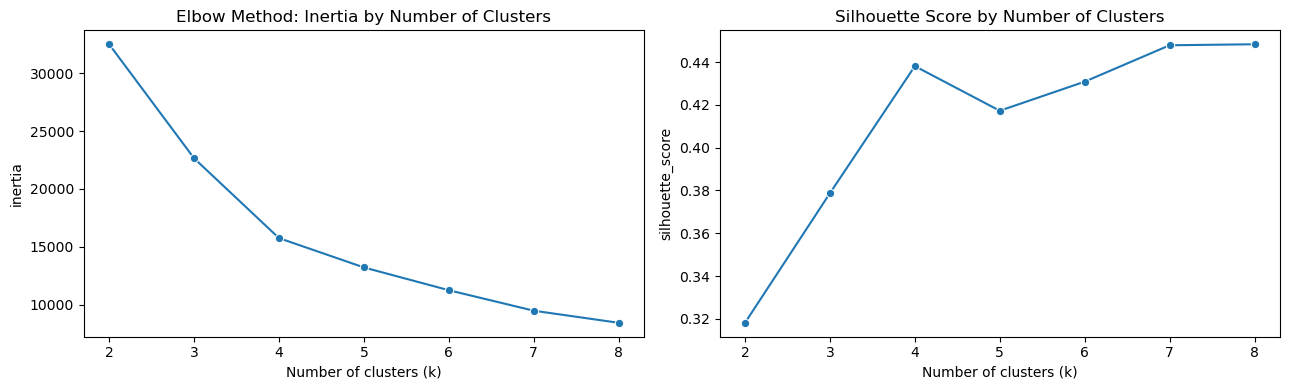

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(data=cluster_results, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow Method: Inertia by Number of Clusters")
axes[0].set_xlabel("Number of clusters (k)")

sns.lineplot(data=cluster_results, x="k", y="silhouette_score", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score by Number of Clusters")
axes[1].set_xlabel("Number of clusters (k)")

plt.tight_layout()
plt.show()

## Selecting the number of customer segments

Four clusters were selected using K-means clustering. The elbow method showed a clear reduction in marginal improvement after four clusters, while the silhouette score at k=4 was 0.4381.

Although k=7 and k=8 produced marginally higher silhouette scores, four segments were selected to balance statistical separation with business interpretability and practical retention actionability.

In [7]:
# Fit the selected K-means model
k_selected = 4

kmeans = KMeans(
    n_clusters=k_selected,
    random_state=42,
    n_init=20
)

df_features["CustomerSegment"] = kmeans.fit_predict(X_scaled)

# Confirm the cluster sizes
df_features["CustomerSegment"].value_counts().sort_index()

CustomerSegment
0    2771
1     682
2    1526
3    2064
Name: count, dtype: int64

In [8]:
segment_profile = (
    df_features.groupby("CustomerSegment")
    .agg(
        customers=("customerID", "count"),
        customer_share=("customerID", lambda x: len(x) / len(df_features)),
        average_tenure=("tenure", "mean"),
        average_monthly_charges=("MonthlyCharges", "mean"),
        average_total_charges=("TotalCharges", "mean"),
        average_service_count=("ServiceCount", "mean"),
        internet_customer_share=("HasInternet", "mean"),
        auto_payment_share=("AutoPayment", "mean"),
        observed_churn_rate=("ChurnFlag", "mean")
    )
    .sort_values("observed_churn_rate", ascending=False)
)

# Format values only for presentation
segment_profile_display = segment_profile.copy()

for column in [
    "customer_share",
    "internet_customer_share",
    "auto_payment_share",
    "observed_churn_rate"
]:
    segment_profile_display[column] = segment_profile_display[column].map("{:.2%}".format)

for column in [
    "average_tenure",
    "average_monthly_charges",
    "average_total_charges",
    "average_service_count"
]:
    segment_profile_display[column] = segment_profile_display[column].round(2)

segment_profile_display

,customers,customer_share,average_tenure,average_monthly_charges,average_total_charges,average_service_count,internet_customer_share,auto_payment_share,observed_churn_rate
CustomerSegment,,,,,,,,,
0,2771,39.34%,14.76,74.08,1107.42,1.63,100.00%,26.20%,46.01%
1,682,9.68%,31.74,42.03,1496.03,2.56,100.00%,43.55%,24.93%
3,2064,29.31%,57.58,92.06,5308.17,3.93,100.00%,66.86%,15.07%
2,1526,21.67%,30.55,21.08,662.60,0.00,0.00%,43.45%,7.40%


In [9]:
for column in ["Contract", "InternetService", "PaymentMethod", "TechSupport"]:
    print(f"\n--- {column} distribution within each segment ---")
    display(
        pd.crosstab(
            df_features["CustomerSegment"],
            df_features[column],
            normalize="index"
        ).round(3)
    )


--- Contract distribution within each segment ---


Contract,Month-to-month,One year,Two year
CustomerSegment,,,
0,0.881,0.103,0.016
1,0.551,0.213,0.236
2,0.343,0.239,0.418
3,0.259,0.329,0.412



--- InternetService distribution within each segment ---


InternetService,DSL,Fiber optic,No
CustomerSegment,,,
0,0.377,0.623,0.0
1,1.000,0.000,0.0
2,0.000,0.000,1.0
3,0.337,0.663,0.0



--- PaymentMethod distribution within each segment ---


PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
CustomerSegment,,,,
0,0.135,0.127,0.532,0.206
1,0.210,0.226,0.331,0.233
2,0.218,0.217,0.080,0.486
3,0.337,0.332,0.263,0.068



--- TechSupport distribution within each segment ---


TechSupport,No,No internet service,Yes
CustomerSegment,,,
0,0.789,0.0,0.211
1,0.576,0.0,0.424
2,0.000,1.0,0.000
3,0.433,0.0,0.567


## Customer-segment profiles

### Segment 0 — High-risk new internet customers
This is the largest segment (39.34%) and has the highest observed churn rate (46.01%). Customers have short tenure, high reliance on month-to-month contracts, frequent electronic-check use, and limited tech-support adoption.

### Segment 1 — Mid-tenure DSL customers
This smaller DSL-only segment has a churn rate of 24.93%, close to the overall dataset churn rate. It represents a moderate-risk customer group with relatively low monthly charges.

### Segment 2 — Basic non-internet customers
These customers do not use internet or add-on services and have the lowest observed churn rate (7.40%). They are a comparatively stable, low-charge segment.

### Segment 3 — Established high-value internet customers
This group has long tenure, the highest service adoption and spending, and a relatively low observed churn rate (15.07%). It is valuable to retain because of its high average monthly and lifetime charges.

In [10]:
segment_names = {
    0: "High-risk new internet customers",
    1: "Mid-tenure DSL customers",
    2: "Basic non-internet customers",
    3: "Established high-value internet customers",
}

df_features["SegmentName"] = (
    df_features["CustomerSegment"].map(segment_names)
)

df_features[["CustomerSegment", "SegmentName"]].drop_duplicates().sort_values(
    "CustomerSegment"
)

,CustomerSegment,SegmentName
1,0,High-risk new internet customers
0,1,Mid-tenure DSL customers
11,2,Basic non-internet customers
9,3,Established high-value internet customers
